# Kepler Exoplanet Detection — Exploratory Data Analysis

**Dataset:** NASA Kepler Exoplanet Search Results (Kaggle)  
**Author:** Ziyad Shaikh  
**Goal:** Understand the dataset structure, identify preprocessing decisions, and justify the ML pipeline design before building it.

This notebook answers 6 questions:
1. What does the dataset look like?
2. What is our target variable and how imbalanced is it?
3. Which columns are useless and should be dropped?
4. How much missing data do we have and how do we handle it?
5. Which features are skewed and need transformation?
6. Which features actually matter for classification?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("data/raw/raw.csv")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Shape: (9564, 50)

Columns: ['rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_disposition', 'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1', 'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1', 'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2', 'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth', 'koi_depth_err1', 'koi_depth_err2', 'koi_prad', 'koi_prad_err1', 'koi_prad_err2', 'koi_teq', 'koi_teq_err1', 'koi_teq_err2', 'koi_insol', 'koi_insol_err1', 'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num', 'koi_tce_delivname', 'koi_steff', 'koi_steff_err1', 'koi_steff_err2', 'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad', 'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec', 'koi_kepmag']


## 1. Dataset Overview

The dataset has **9,564 rows and 50 columns**. Each row is a Kepler Object of Interest (KOI) — a celestial object that triggered the Kepler telescope's planet-detection algorithm.

Columns fall into 4 groups:
- **Metadata / IDs** — `rowid`, `kepid`, `kepoi_name`, `kepler_name`, `ra`, `dec` — these identify the object but carry no predictive signal
- **Target** — `koi_disposition` — what the object was classified as after review
- **Transit parameters** — measurements from the light curve: period, duration, depth, impact, planet radius
- **Stellar parameters** — properties of the host star: temperature, surface gravity, stellar radius

The `koi_score` column is the Kepler pipeline's own confidence score — we will investigate whether including it causes data leakage.

In [3]:
print(df.dtypes)
print("\n")
print(df.head(3).T)

rowid                  int64
kepid                  int64
kepoi_name            object
kepler_name           object
koi_disposition       object
koi_pdisposition      object
koi_score            float64
koi_fpflag_nt          int64
koi_fpflag_ss          int64
koi_fpflag_co          int64
koi_fpflag_ec          int64
koi_period           float64
koi_period_err1      float64
koi_period_err2      float64
koi_time0bk          float64
koi_time0bk_err1     float64
koi_time0bk_err2     float64
koi_impact           float64
koi_impact_err1      float64
koi_impact_err2      float64
koi_duration         float64
koi_duration_err1    float64
koi_duration_err2    float64
koi_depth            float64
koi_depth_err1       float64
koi_depth_err2       float64
koi_prad             float64
koi_prad_err1        float64
koi_prad_err2        float64
koi_teq              float64
koi_teq_err1         float64
koi_teq_err2         float64
koi_insol            float64
koi_insol_err1       float64
koi_insol_err2

## 2. Target Variable — Class Imbalance

`koi_disposition` is our target. It has 3 values:
- `CONFIRMED` — verified exoplanet
- `FALSE POSITIVE` — not a planet
- `CANDIDATE` — unverified, still under review

**Decision:** Drop CANDIDATE rows. We cannot use uncertain labels for training — they would introduce noise. We only train on what we know for certain.

After dropping CANDIDATEs, we encode: `CONFIRMED = 1`, `FALSE POSITIVE = 0`.

Full disposition counts:
koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64

After dropping CANDIDATE: (7316, 50)
koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
Name: count, dtype: int64


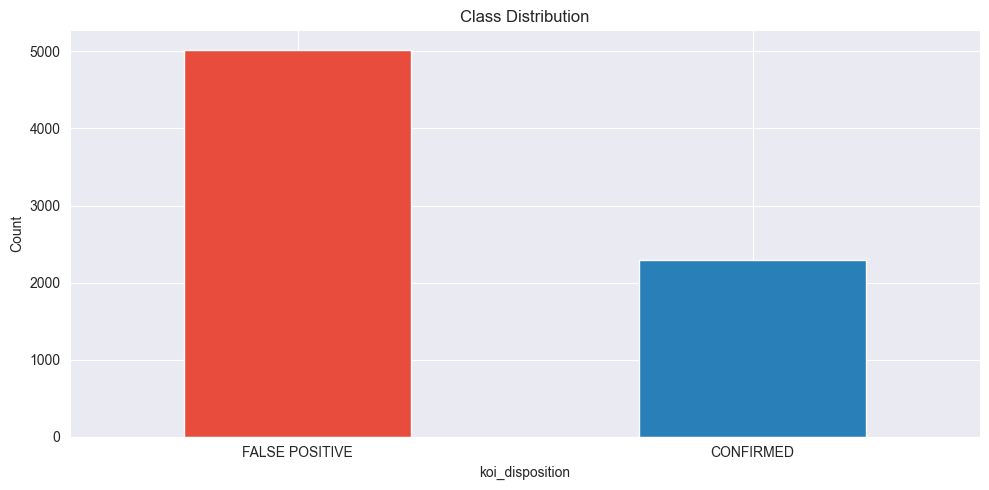

In [4]:
print("Full disposition counts:")
print(df["koi_disposition"].value_counts())

df = df[df["koi_disposition"].isin(["CONFIRMED", "FALSE POSITIVE"])]
print(f"\nAfter dropping CANDIDATE: {df.shape}")
print(df["koi_disposition"].value_counts())

df["koi_disposition"].value_counts().plot(kind="bar", color=["#e74c3c", "#2980b9"])
plt.title("Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Dropping Useless Columns

Removing metadata, ID columns, and fully empty columns before modelling.
`koi_teq_err1` and `koi_teq_err2` are 100% missing — dropped entirely.
`koi_score` is the Kepler pipeline's own confidence score — dropping it to avoid data leakage.

In [5]:
drop_cols = [
    "rowid", "kepid", "kepoi_name", "kepler_name",
    "ra", "dec", "koi_pdisposition", "koi_tce_delivname",
    "koi_teq_err1", "koi_teq_err2", "koi_score"
]

df = df.drop(columns=drop_cols)
print(f"Shape after dropping: {df.shape}")
print(df.isnull().sum().sort_values(ascending=False).head(15))

Shape after dropping: (7316, 39)
koi_steff_err2       412
koi_srad_err1        397
koi_srad_err2        397
koi_slogg_err1       397
koi_steff_err1       397
koi_slogg_err2       397
koi_period_err1      377
koi_depth_err2       377
koi_depth_err1       377
koi_time0bk_err2     377
koi_impact_err1      377
koi_impact_err2      377
koi_duration_err1    377
koi_period_err2      377
koi_time0bk_err1     377
dtype: int64


## 4. Missing Values — Median Imputation

Remaining missing values are in measurement uncertainty columns.
Using median imputation — more robust than mean for skewed scientific data.

In [6]:
df = df.fillna(df.median(numeric_only=True))
print(f"Missing values after imputation: {df.isnull().sum().sum()}")

Missing values after imputation: 0

## 5. Skewed Features — Log Transformation

`koi_period`, `koi_prad`, `koi_depth`, `koi_insol` are heavily right-skewed.
Applying log1p to normalise distributions.

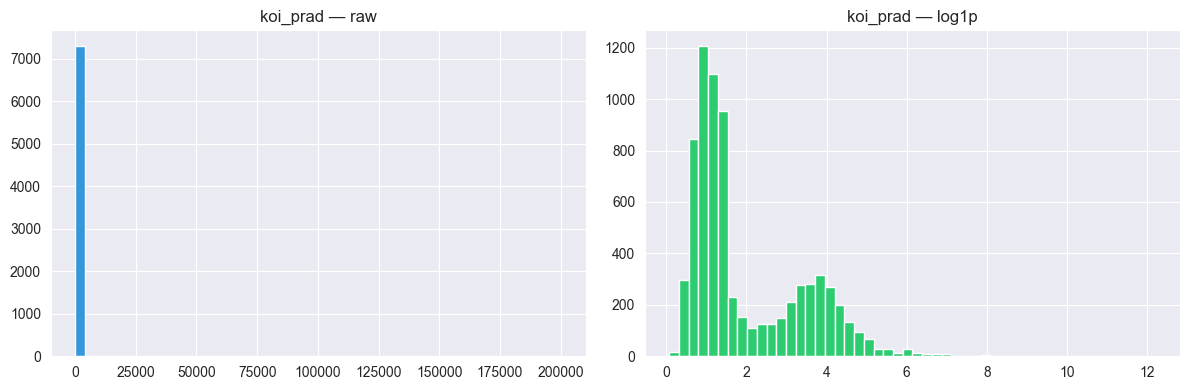

Log transformation applied.


In [7]:
skewed_cols = ["koi_period", "koi_prad", "koi_depth", "koi_insol"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["koi_prad"].hist(bins=50, ax=axes[0], color="#3498db")
axes[0].set_title("koi_prad — raw")

np.log1p(df["koi_prad"]).hist(bins=50, ax=axes[1], color="#2ecc71")
axes[1].set_title("koi_prad — log1p")
plt.tight_layout()
plt.show()

for col in skewed_cols:
    df[col] = np.log1p(df[col])
print("Log transformation applied.")

## 6. Feature Distributions by Class

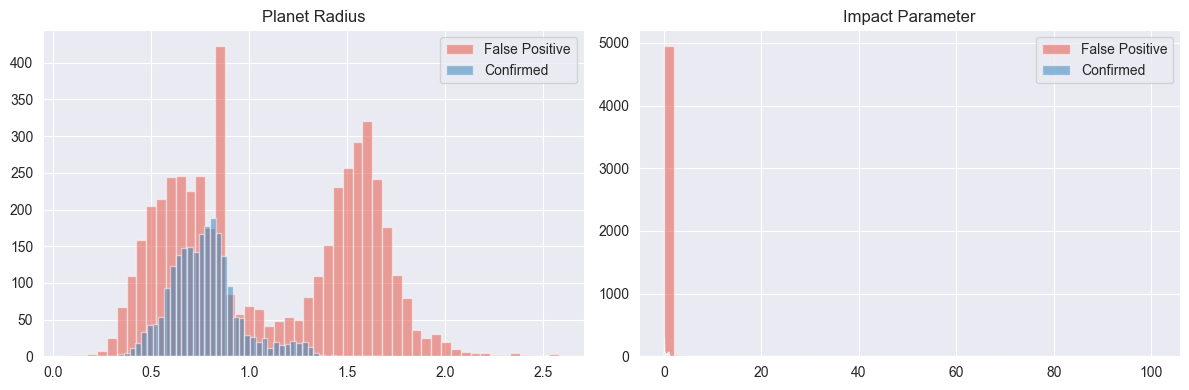

In [8]:
confirmed = df[df["koi_disposition"] == "CONFIRMED"]
false_pos = df[df["koi_disposition"] == "FALSE POSITIVE"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

np.log1p(false_pos["koi_prad"]).hist(bins=50, ax=axes[0], alpha=0.5, label="False Positive", color="#e74c3c")
np.log1p(confirmed["koi_prad"]).hist(bins=50, ax=axes[0], alpha=0.5, label="Confirmed", color="#2980b9")
axes[0].legend()
axes[0].set_title("Planet Radius")

false_pos["koi_impact"].hist(bins=50, ax=axes[1], alpha=0.5, label="False Positive", color="#e74c3c")
confirmed["koi_impact"].hist(bins=50, ax=axes[1], alpha=0.5, label="Confirmed", color="#2980b9")
axes[1].legend()
axes[1].set_title("Impact Parameter")

plt.tight_layout()
plt.show()

## 7. Encode Target and Final Shape

In [9]:
df["label"] = (df["koi_disposition"] == "CONFIRMED").astype(int)
df = df.drop(columns=["koi_disposition"])

print(f"Final shape: {df.shape}")
print(df["label"].value_counts())
print(f"\nFeatures: {df.shape[1] - 1}")

Final shape: (7316, 39)
label
0    5023
1    2293
Name: count, dtype: int64

Features: 38
